# Meta Analysis

SEOYEON CHOI  
2025-10-05

[Reference](https://wikidocs.net/229908)

# 0. 정의

Meta analysis: 별도의 연구 결과를 통계적으로 결합하는 과정으로 여러
독립적인 연구 결과를 하나로 통합하는 작업

1.  문헌 검토
2.  데이터 시트 작성
3.  효과 크기 계산
4.  메타 분석 결과 해석

# 1. 문헌 검토

-   연구 질문 정의
-   키워드 식별
-   검색 전략 정의
-   수집된 논문에서 분석 결과 추출

# 2. 데이터 시트 작성

-   분석 유형
    -   여러 연구해서 결론이 내려진 분석 결과를 수식을 통한 계산 작업을
        거쳐 표준화된 값으로 변환
-   데이터 유형
    -   범주형 유형
        -   명목 척도
        -   순위 척도
    -   연속형 유형
        -   등간 척도
        -   비율 척도

# 3. 효과 크기

ttest,anova,correation analysis 등에서 제시된 다양한 연구결과로 아래를
계산

-   주의할 점은 표본이 작은 경우 효과 크기가 과대추정될 수 있으니 샘플
    수를 확인해야 한다는 것

-   효과 크기

    -   표준화된 평균차이
        -   Cohen
    -   두 집단의 비율
        -   Odds ratio
    -   두 변수 간의 상관관계
        -   Correlation

-   Cohen’s Effect size: $d = \frac{\bar{X} - \bar{X}}{S}$

    -   \<=0.2 작은 효과, 0.2~0.8 중간 효과, \>=0.8 큰 효과

연구 결과에서 효과 크기, 신뢰구간, 가중치 해석

-   가중치
    -   샘플 수가 달라서 효과 크기 계산에 영향을 줄 수 있어서 조정해줘야
        함
-   $J = (1-\frac{3}{4df-1})$
-   Hedges’ Effect Size = $g = d\times J$

이질성 검증

-   $I^2 = \frac{Q-df}{Q} \times 100$
    -   0% ~ 25% 이질성이 낮음
    -   25% ~ 75% 중간정도의 이질성이 있음
    -   75% ~ 100% 이질성이 높음
-   $I^2$가 50% 이상이고, 이질성 검증의 유의확률 p-value가 p\<0.1인 경우
    효과 크기의 이질성이 있는 것으로 판단하고 고정 효과 모델 대신 랜덤
    효과 모델 선택
    -   랜덤 효과 모델은 더 보수적인 신뢰구간 제공
-   고정 효과 모델 선택하려면 동일한 모딥단에서 추출한 표본의 경우에
    사용 가능.
    -   일반화 어려움
-   랜덤 표과 모델
    -   메타 분석은 다양한 연구를 포함하기 때문에 표본 집단이 다른
        경우가 많다.

출판 오류,평향 분석

-   연구 결과의 신뢰성과 타당성을 보장하기 위함

-   메타 분석이 실제 효과를 과대 또는 과소 추정할 수 있음

-   좌우 대칭으로 나오면 편향이 없는 것으로 보지만, 비대칭 분포를 가지면
    편향이 있는 것으로 봄

-   일반적으로 안전계수 값이 $5 \times N + 10$ 여기서 N은 메타분석
    논문수 보다 크면 대체로 안전하다고 판단

# 4. 실습

-   Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, log, exp

1.  예제 데이터
    -   a = treatment effect
    -   b = treatment non-events
    -   c = control events
    -   d = control non-events

In [8]:
df = pd.DataFrame({
    "study": ["Study A","Study B","Study C","Study D","Study E","Study F"],
    "a": [22, 18, 15, 40, 27, 12],
    "b": [78, 82, 75, 160,123, 68],
    "c": [30, 25, 24, 50, 35, 11],
    "d": [70, 75, 66, 150,115, 69],
})
df

1.  효과 크기 계산

In [9]:
def log_or_and_se(a,b,c,d, add0_5=True):
    if add0_5 and min(a,b,c,d) == 0:
        a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
    logOR = log((a*d)/(b*c))
    SE = sqrt(1/a + 1/b + 1/c + 1/d)
    return logOR, SE

In [10]:
Z = 1.96  # 95% CI

In [11]:
df["logOR"], df["SE"] = zip(*df.apply(lambda r: log_or_and_se(r.a,r.b,r.c,r.d), axis=1))
df["logLCL"] = df["logOR"] - Z*df["SE"]
df["logUCL"] = df["logOR"] + Z*df["SE"]

In [12]:
# OR 스케일로 보기
df["OR"]    = np.exp(df["logOR"])
df["OR_LCL"]= np.exp(df["logLCL"])
df["OR_UCL"]= np.exp(df["logUCL"])

In [13]:
df.round(3)

1.  고정효과 메타분석

In [14]:
w_fixed = 1 / (df["SE"]**2)
theta_fixed = np.sum(w_fixed * df["logOR"]) / np.sum(w_fixed)      # 가중 평균
se_fixed = sqrt(1 / np.sum(w_fixed))
fixed_L = theta_fixed - Z*se_fixed
fixed_U = theta_fixed + Z*se_fixed

print("Fixed-effect (log scale):", theta_fixed, "±", se_fixed)
print("Fixed-effect (OR):", exp(theta_fixed), 
      "(95% CI", exp(fixed_L), "to", exp(fixed_U), ")")

Fixed-effect (log scale): -0.34053900893309863 ± 0.12983334833335455
Fixed-effect (OR): 0.7113867755772918 (95% CI 0.551555742161936 to 0.9175339966230908 )

-   pooled OR 통합오즈비 = 0.71
    -   1보다 작다는 건 치료가 더 좋은 효과
    -   치료군의 사건 발생 odds가 대조군 대비 약 29% 감소
-   95% CI = 0.55, 0.92
    -   95% CI가 1을 포함하지 않음
    -   따라서 통계적으로 유의한 차이 존재

1.  이질성

In [15]:
Q = np.sum(w_fixed * (df["logOR"] - theta_fixed)**2)
df_Q = len(df) - 1
I2 = max(0.0, (Q - df_Q) / Q) * 100 if Q > 0 else 0.0

print(f"Heterogeneity: Q={Q:.2f}, df={df_Q}, I²={I2:.1f}%")

Heterogeneity: Q=1.60, df=5, I²=0.0%

-   이질성은 1.60
-   $I^2$으로 보아 효과 크기 차이가 거의 없음.
-   따라서 모든 연구들이 일관된 방향을 보여줌
-   이질성이 낮으므로 고정효과 모델 결과와 랜덤 표과 모델 결과가 거의
    동일하게 나올 것으로 예상

1.  랜덤 효과

In [16]:
den = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))
tau2 = max(0.0, (Q - df_Q) / den)  # between-study variance (DL)

w_random = 1 / (df["SE"]**2 + tau2)
theta_random = np.sum(w_random * df["logOR"]) / np.sum(w_random)
se_random = sqrt(1 / np.sum(w_random))
random_L = theta_random - Z*se_random
random_U = theta_random + Z*se_random

print("Random-effects (log):", theta_random, "±", se_random, " | tau²=", tau2)
print("Random-effects (OR):", exp(theta_random), 
      "(95% CI", exp(random_L), "to", exp(random_U), ")")

Random-effects (log): -0.34053900893309863 ± 0.12983334833335455  | tau²= 0.0
Random-effects (OR): 0.7113867755772918 (95% CI 0.551555742161936 to 0.9175339966230908 )

-   $tau^2$ 값으로 보아 betwee-study variance가 거의 없음
-   따라서 pooled OR이 고정 효과 모델과 동일하게 계산된다.

1.  포레스트 플롯

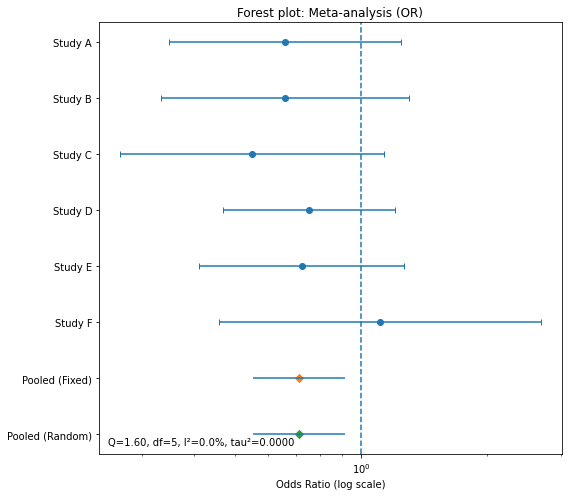

In [19]:
y = np.arange(len(df), 0, -1)

fig, ax = plt.subplots(figsize=(8,7))
ax.errorbar(df["OR"], y,
            xerr=[df["OR"]-df["OR_LCL"], df["OR_UCL"]-df["OR"]],
            fmt='o', capsize=3)

# 고정/랜덤 풀드 효과(다이아몬드 마커)
ax.plot(np.exp(theta_fixed), 0, marker='D')
ax.hlines(0, np.exp(fixed_L), np.exp(fixed_U))

ax.plot(np.exp(theta_random), -1, marker='D')
ax.hlines(-1, np.exp(random_L), np.exp(random_U))

ax.axvline(1.0, linestyle='--')
ax.set_xscale("log")
ax.set_xlabel("Odds Ratio (log scale)")
ax.set_yticks(list(y) + [0, -1])
ax.set_yticklabels(list(df["study"]) + ["Pooled (Fixed)", "Pooled (Random)"])
ax.set_title("Forest plot: Meta-analysis (OR)")
ax.text(0.02, 0.02, f"Q={Q:.2f}, df={df_Q}, I²={I2:.1f}%, tau²={tau2:.4f}",
        transform=ax.transAxes)
plt.tight_layout()
plt.show()

-   대부분의 연구 결과가 왼쪽에 위치, OR \<1
-   pooled fixed, pooled random이 1보다 왼쪽에 위치
-   전반적인 치료가 효과적임을 시각적으로 확인할 수 있음